In [61]:
# Run this cell first (installs quietly if something is missing)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [42]:
# Step 1: Load the dataset directly from the internet using pandas
url = "https://raw.githubusercontent.com/krishnaik06/simple-Linear-Regression/master/Salary_Data.csv"
salary_df = pd.read_csv(url)

# Let's peek at the first 5 rows
salary_df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [43]:
# Step 2: Quick look at the data
print("Shape of data (rows, columns):", salary_df.shape)
print()
print(salary_df.describe())  # basic statistics: mean, min, max, etc.

Shape of data (rows, columns): (30, 2)

       YearsExperience         Salary
count        30.000000      30.000000
mean          5.313333   76003.000000
std           2.837888   27414.429785
min           1.100000   37731.000000
25%           3.200000   56720.750000
50%           4.700000   65237.000000
75%           7.700000  100544.750000
max          10.500000  122391.000000


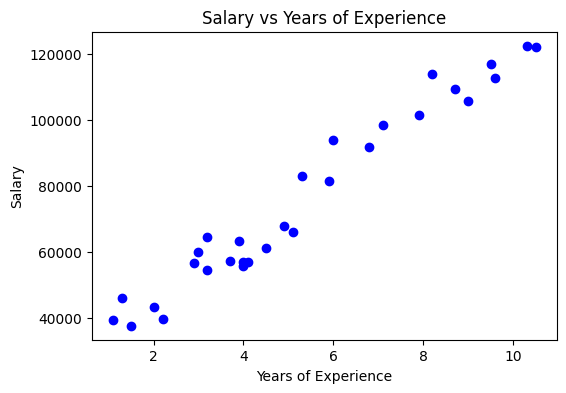

In [44]:
# Step 3: Visualize the data before doing anything else
# This helps us SEE if a straight line even makes sense here
plt.figure(figsize=(6,4))
plt.scatter(salary_df["YearsExperience"], salary_df["Salary"], color="blue")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary vs Years of Experience")
plt.show()

In [45]:
# Step 4: Split data into features (X) and target (y)
# X = the input(s) we use to predict.  y = the value we want to predict.
X = salary_df[["YearsExperience"]]   # double brackets = keep it as a table (DataFrame)
y = salary_df["Salary"]              # single bracket = a simple column (Series)

# Now split into training data and testing data
# test_size=0.2 means: 20% of the data goes to testing, 80% goes to training
# random_state=42 just makes the split reproducible (same split every time you run it)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training rows:", X_train.shape[0])
print("Testing rows :", X_test.shape[0])

Training rows: 24
Testing rows : 6


In [46]:
# Step 5: Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)   # <-- this is where the "learning" happens

print("Learned slope (coefficient):", model.coef_[0])
print("Learned intercept (starting point):", model.intercept_)

Learned slope (coefficient): 9423.815323030976
Learned intercept (starting point): 25321.583011776813


In [47]:
# Step 6: Predict salaries for the test set
y_pred = model.predict(X_test)

# Let's compare actual vs predicted side-by-side
comparison_df = pd.DataFrame({
    "Actual Salary": y_test.values,
    "Predicted Salary": y_pred.round(2)
})
comparison_df

,Actual Salary,Predicted Salary
0,112635.0,115790.21
1,67938.0,71498.28
2,113812.0,102596.87
3,83088.0,75267.80
4,64445.0,55477.79
5,57189.0,60189.70


In [48]:

# Step 7: Evaluate
mae_20 = mean_absolute_error(y_test, y_pred)
r2_20 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae_20:.2f}  (on average, predictions are off by this much)")
print(f"R2 Score: {r2_20:.3f}  (1.0 = perfect fit, 0 = no better than guessing the average)")

Mean Absolute Error: 6286.45  (on average, predictions are off by this much)
R2 Score: 0.902  (1.0 = perfect fit, 0 = no better than guessing the average)


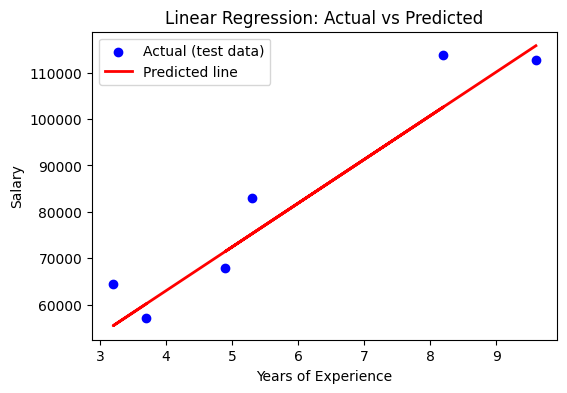

In [49]:
# Step 8: Visualize the regression line against the TEST data
plt.figure(figsize=(6,4))
plt.scatter(X_test, y_test, color="blue", label="Actual (test data)")
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Predicted line")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Linear Regression: Actual vs Predicted")
plt.legend()
plt.show()

Predict for a brand-new employee

In [50]:
new_experience = pd.DataFrame({"YearsExperience": [7.5]})
predicted_salary = model.predict(new_experience)
print(f"Predicted salary for 7.5 years of experience: {predicted_salary[0]:.2f}")

Predicted salary for 7.5 years of experience: 96000.20


Change `test_size` to 0.3 in **does** accuracy/R² change much?


In [51]:
# Split data into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows :", X_test.shape[0])

Training rows: 21
Testing rows : 9


In [52]:
# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Learned slope (coefficient):", model.coef_[0])
print("Learned intercept (starting point):", model.intercept_)

Learned slope (coefficient): 9339.081723815198
Learned intercept (starting point): 25918.438334893202


In [53]:
# Predict salaries for the test set
y_pred = model.predict(X_test)

comparison_df = pd.DataFrame({
    "Actual Salary": y_test.values,
    "Predicted Salary": y_pred.round(2)
})

comparison_df

,Actual Salary,Predicted Salary
0,112635.0,115573.62
1,67938.0,71679.94
2,113812.0,102498.91
3,83088.0,75415.57
4,64445.0,55803.50
5,57189.0,60473.04
6,122391.0,122110.98
7,109431.0,107168.45
8,56957.0,63274.77


In [54]:
# Evaluate
mae_30 = mean_absolute_error(y_test, y_pred)
r2_30 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae_30:.2f}")
print(f"R2 Score: {r2_30:.3f}")

Mean Absolute Error: 5161.33
R2 Score: 0.941


In [55]:
print("20% Test → MAE:", round(mae_20, 2), "R²:", round(r2_20, 3))
print("30% Test → MAE:", round(mae_30, 2), "R²:", round(r2_30, 3))

20% Test → MAE: 6286.45 R²: 0.902
30% Test → MAE: 5161.33 R²: 0.941


# PART 2 - Logistic Regression


In [57]:
# Step 1: Load the diabetes dataset
diabetes_url = "https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv"
diabetes_df = pd.read_csv(diabetes_url)

diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [58]:
# Step 2: Quick look
print("Shape:", diabetes_df.shape)
print()
print("How many patients have diabetes (1) vs not (0)?")
print(diabetes_df["Outcome"].value_counts())

Shape: (768, 9)

How many patients have diabetes (1) vs not (0)?
Outcome
0    500
1    268
Name: count, dtype: int64


In [59]:
X = diabetes_df.drop(columns=["Outcome"])
y = diabetes_df["Outcome"]

X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # keeps the Yes/No ratio similar in both train and test sets
)

print("Training rows:", X_train.shape[0])
print("Testing rows :", X_test.shape[0])

Training rows: 614
Testing rows : 154


Train the Logistic Regression model

In [62]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

print("Model trained!")

Model trained!


Predict on the test set

In [63]:
y_pred = log_model.predict(X_test)

# Compare a handful of actual vs predicted values
comparison_df = pd.DataFrame({
    "Actal": y_test.values[:10],
    "Predicted": y_pred[:10]
})
comparison_df


,Actal,Predicted
0,0,1
1,0,0
2,0,0
3,1,0
4,0,0
5,0,0
6,1,0
7,1,1
8,0,0
9,0,1


Evaluate the model

Accuracy: 71.43%


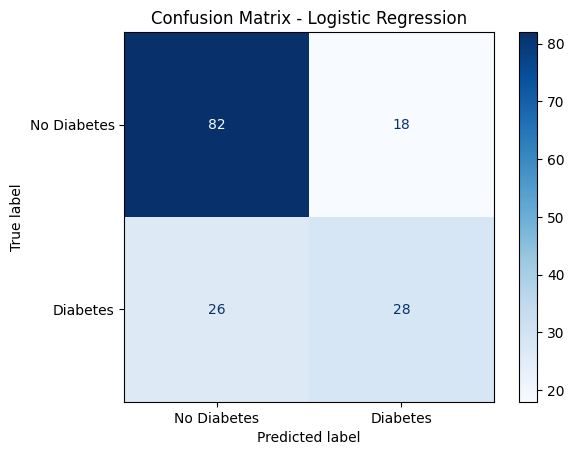

In [65]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Diabetes", "Diabetes"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

Predict for a brand-new patient

In [66]:
new_patient = pd.DataFrame([{
    "Pregnancies": 2,
    "Glucose": 150,
    "BloodPressure": 80,
    "SkinThickness": 30,
    "Insulin": 100,
    "BMI": 32.5,
    "DiabetesPedigreeFunction": 0.5,
    "Age": 45
}])

prediction = log_model.predict(new_patient)[0]
probability = log_model.predict_proba(new_patient)[0][1]  # probability of class "1" (has diabetes)

result = "Diabetes" if prediction == 1 else "No Diabetes"
print(f"Prediction: {result}")
print(f"Probability of diabetes: {probability:.2%}")

Prediction: Diabetes
Probability of diabetes: 53.22%


Changing the values in `new_patient` and see how the prediction changes.

In [67]:
new_patient = pd.DataFrame([{
    "Pregnancies": 5,
    "Glucose": 180,
    "BloodPressure": 90,
    "SkinThickness": 35,
    "Insulin": 150,
    "BMI": 38.0,
    "DiabetesPedigreeFunction": 0.8,
    "Age": 55
}])

prediction = log_model.predict(new_patient)[0]
probability = log_model.predict_proba(new_patient)[0][1]

result = "Diabetes" if prediction == 1 else "No Diabetes"

print(f"Prediction: {result}")
print(f"Probability of diabetes: {probability:.2%}")

Prediction: Diabetes
Probability of diabetes: 90.93%
